2. Task

Here, we use the heart disease dataset. Each sample has the following feature:

- age
- sex
- chest pain type (4 values)
- resting blood pressure
- serum cholestoral in mg/dl
- fasting blood sugar > 120 mg/dl
- resting electrocardiographic results (values 0,1,2)
- maximum heart rate achieved
- exercise induced angina
- oldpeak = ST depression induced by exercise relative to rest
- the slope of the peak exercise ST segment
- number of major vessels (0-3) colored by flourosopy
- thal: 3 = normal; 6 = fixed defect; 7 = reversable defect

The last column refers to the presence of heart disease in the patient.

The task is to predict whether a person has the heart disease.

2.1 Preprocess the raw data
- Check whether there are missing values
- Check whether theare are cateogrical features
- Check whether this dataset is balanced or not (use the bar plot to visualize the number of positive and negative samples)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


Text(0.5, 1.0, 'Number of People With and Without Heart Disease')

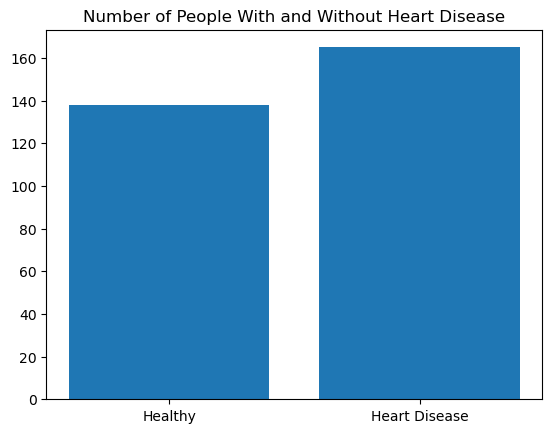

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
from random import shuffle

df = pd.read_csv('heart.csv')

print(df.isnull().sum())

print(df.info())

plt.bar(df['target'].value_counts().index, df['target'].value_counts().values, tick_label=['Heart Disease', 'Healthy'])
plt.title('Number of People With and Without Heart Disease')

2.2 Split the data into two subsets and normalize the features of samples
Split the dataset into the train_val set and testing set.
Normalize features

In [3]:
heart_data = df.drop('target', axis=1).values
heart_disease = df['target'].values
X_train_val, X_test, y_train_val, y_test = train_test_split(heart_data, heart_disease, 
                                                            test_size=0.14, 
                                                            random_state=0)

print("train_val: {}, test: {}".format(X_train_val.shape[0], X_test.shape[0]))

normalizer = StandardScaler()
X_train_val = normalizer.fit_transform(X_train_val)
X_test = normalizer.transform(X_test)

train_val: 260, test: 43


2.3 Train the logistic regression model and select the hyperparameter with cross-validation
 
 - Use the 10-fold cross-validation to select the hyperparameter lambda
 - Search lambda from 

In [5]:
folds = 10

num_train_val = X_train_val.shape[0]

index_of_samples = np.arange(num_train_val) 
shuffle(index_of_samples)

index_of_folds = index_of_samples.reshape(folds, -1)

regularization_coefficient = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 20, 50, 100]

best_acc = 0.0
best_reg = 0.0

for reg in regularization_coefficient:
    
    sum_acc = 0.0
    for fold in range(folds):
        
        index_of_folds_temp = index_of_folds.copy()
        
        valid_index = index_of_folds_temp[fold,:].reshape(-1)
        train_index = np.delete(index_of_folds_temp, fold, 0).reshape(-1)
        
        X_train = X_train_val[train_index]
        y_train = y_train_val[train_index]
        
        X_valid = X_train_val[valid_index]
        y_valid = y_train_val[valid_index]
        
        clf = LogisticRegression(penalty='l2', C=reg, solver='lbfgs')
        clf.fit(X_train, y_train)
        
        y_valid_pred = clf.predict(X_valid)
        acc = accuracy_score(y_valid, y_valid_pred)
        
        sum_acc += acc
    
    cur_acc = sum_acc / folds
    
    print("reg_coeff: {}, acc: {:.3f}".format(1.0/reg, cur_acc))
    
    # store the best hyperparameter
    if cur_acc > best_acc:
        best_acc = cur_acc
        best_reg = reg
        
print(str(best_reg))

reg_coeff: 99999.99999999999, acc: 0.554
reg_coeff: 10000.0, acc: 0.554
reg_coeff: 1000.0, acc: 0.681
reg_coeff: 100.0, acc: 0.827
reg_coeff: 10.0, acc: 0.823
reg_coeff: 1.0, acc: 0.823
reg_coeff: 0.1, acc: 0.815
reg_coeff: 0.05, acc: 0.815
reg_coeff: 0.02, acc: 0.815
reg_coeff: 0.01, acc: 0.815
0.01


2.4 Evaluate the learned model
- Report the prediction accuracy, recall, precision, and F1 score.

- Use the bar plot to visulaize the elements of the learned model parameter vector w. Some elements have larger absolute values, while the others do not. Try to explain this phenomenon.

accuracy: 0.791, recall: 0.905, precision: 0.731, f1: 0.809,


Text(0.5, 1.0, 'Learned Model Parameters')

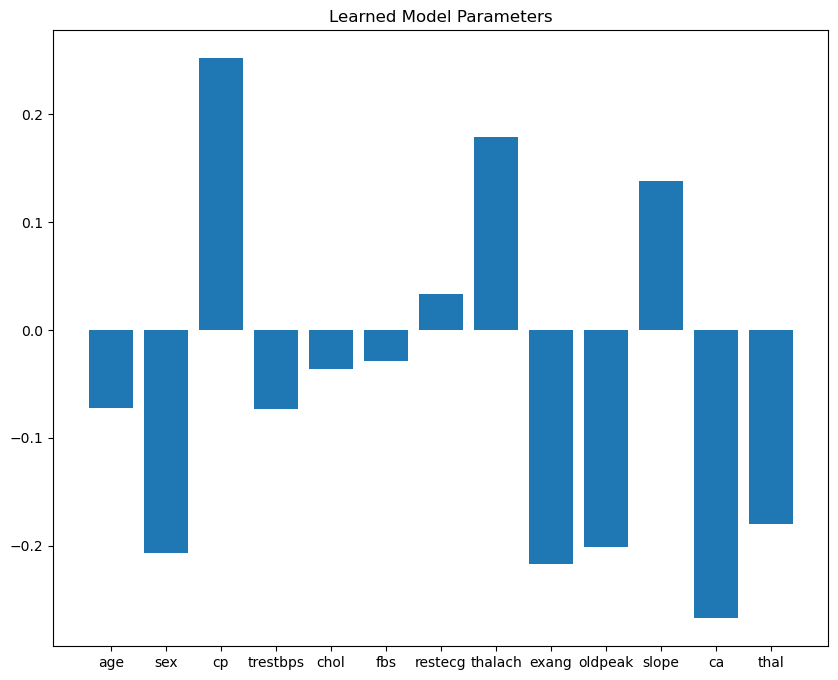

In [6]:
clf = LogisticRegression(penalty='l2', C=best_reg, solver='lbfgs')
clf.fit(X_train_val, y_train_val)

y_test_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)


print("accuracy: {:.3f}, recall: {:.3f}, precision: {:.3f}, f1: {:.3f},".format(acc, recall, precision, f1))

fig = plt.figure(1, [10, 8])
plt.bar(df.columns[:-1], clf.coef_[0], figure=fig)
plt.title('Learned Model Parameters')